In [1]:
import os, glob, sys
from pathlib import Path
import pandas as pd
import numpy as np
from astropy.io import fits
from scipy.signal import convolve2d
from scipy.ndimage import gaussian_filter

In [2]:
def load_vel_mean(v_files, trange):
    "Load the velocity files and average over a time range"
    vxs = []
    vys = []
    vx_files_subset = v_files[0][trange[0]:trange[1]]
    vy_files_subset = v_files[1][trange[0]:trange[1]]
    for vxf, vyf in zip(vx_files_subset, vy_files_subset):
        vxs.append(fits.getdata(vxf))
        vys.append(fits.getdata(vyf))
    # Get the mean of the velocity components
    vx = np.array(vxs).mean(axis=0)
    vy = np.array(vys).mean(axis=0)
    return vx, vy


def smooth_vel(vxs, vys, fwhm, kernel='boxcar'):
    """ Smooth the velocity with a smoothing kernel that can either be:
     - boxcar: width set to fwhm
     - gaussian: parametrized by fwhm.

     Returns the smoothed velocity components
    """

    if kernel == 'boxcar':
        box = np.ones([fwhm, fwhm]) / fwhm**2
        vxs2 = convolve2d(vxs, box, mode='same')
        vys2 = convolve2d(vys, box, mode='same')
    elif kernel == 'gaussian':
        sigma = fwhm / 2.35
        vxs2 = gaussian_filter(vxs, sigma=sigma, order=0)
        vys2 = gaussian_filter(vys, sigma=sigma, order=0)
    else:
        sys.exit('invalid kernel')

    return vxs2, vys2


def calc_c_pearson(vx1, vx2, vy1, vy2, fov=None):
    if fov is None:
        vx1f, vx2f, vy1f, vy2f = vx1, vx2, vy1, vy2
    else:
        vx1f, vx2f, vy1f, vy2f = vx1[fov], vx2[fov], vy1[fov], vy2[fov]
    c_pearson = np.sum(vx1f*vx2f + vy1f*vy2f) / np.sqrt(np.sum(vx1f**2 + vy1f**2)*np.sum(vx2f**2 + vy2f**2))
    return c_pearson

ker = 'gaussian'

In [ ]:
columns = ['index', 'kernel', 'rs', 'intsteps', 'ballspacing', 'am', 'dp', 'sigma_factor', 'fourier_radius', 'corr', 'corr_top', 'corr_bot', 'RMSE_cal_vx_top', 'MAE_cal_vx_top', 'MAE_cal_vx_bot', 'MAE_cal_vx', 'MAPE', 'MAE_discrep', 'MAPD', 'p_top_0', 'p_bot_0']
filepath = Path(os.environ['DATA'],'stein_series/calibration/correlation_dataframe_gaussian.csv')

caldf = pd.read_csv(filepath, usecols=columns, index_col='index')
print(len(caldf))
caldf = caldf[caldf['kernel'] == 'gaussian']
caldf.drop(['kernel', 'rs'], axis=1, inplace=True)


# Convert 'am' to an ordered categorical type before plotting
am_order = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
sigma_order = [1.0, 1.25, 1.5, 1.75, 2]
caldf['am'] = pd.Categorical(caldf['am'], categories=am_order, ordered=True)
caldf['sigma_factor'] = pd.Categorical(caldf['sigma_factor'], categories=sigma_order, ordered=True)

caldf.head()


9600


,intsteps,ballspacing,am,dp,sigma_factor,fourier_radius,corr,corr_top,corr_bot,MAE_cal_vx,MAE_cal_vx_top,MAE_cal_vx_bot,RMSE_cal_vx_top,MAE_discrep,MAPE,MAPD,p_top_0,p_bot_0
index,,,,,,,,,,,,,,,,,,
0,3,1,0.3,0.1,1.0,0,0.922981,0.913938,0.895334,146.329870,154.809757,172.289996,193.121122,97.295436,21.227198,14.982182,5.906211,6.669520
1,3,1,0.3,0.1,1.0,1,0.965575,0.959947,0.953465,100.424668,108.190630,115.133573,137.846018,67.280075,15.831602,10.900087,6.482791,8.548014
2,3,1,0.3,0.1,1.0,2,0.966088,0.960027,0.955913,100.182181,107.367617,110.997128,135.634257,64.712112,15.814093,10.069174,6.259760,8.153417
3,3,1,0.3,0.1,1.0,3,0.964930,0.958403,0.954201,101.785723,110.003971,116.923487,138.236585,67.528518,15.997625,11.099836,5.936736,7.583757
4,3,1,0.3,0.1,1.0,4,0.964295,0.958078,0.954129,102.244107,109.964214,116.296661,138.796107,66.010454,15.934025,10.780352,5.602860,6.960169


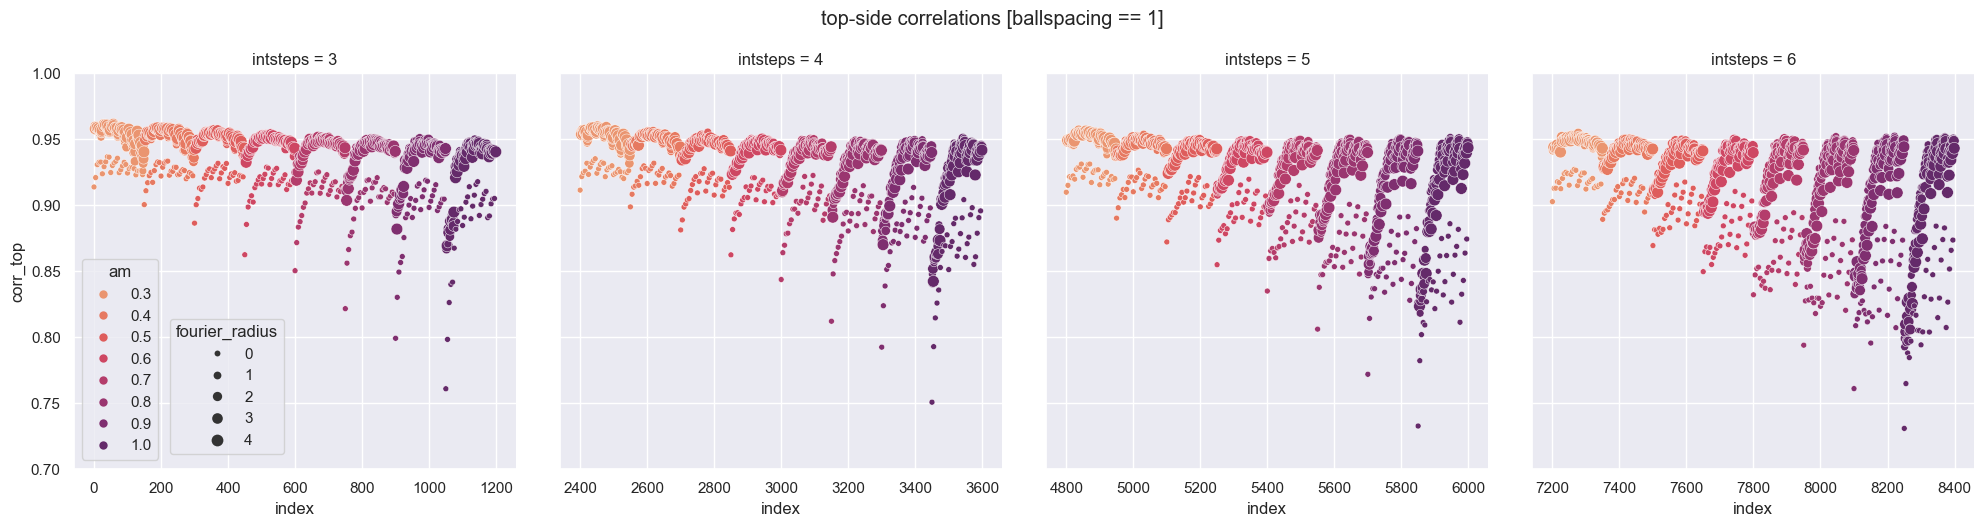

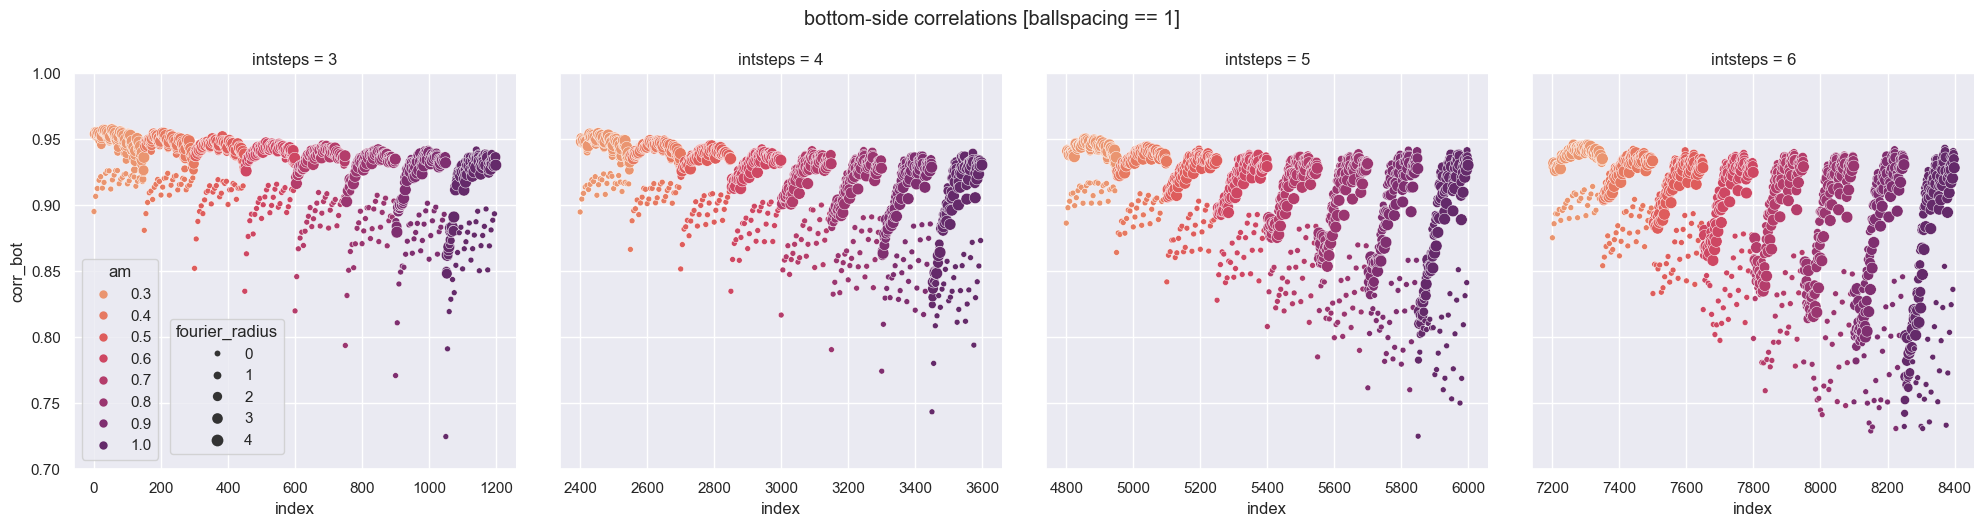

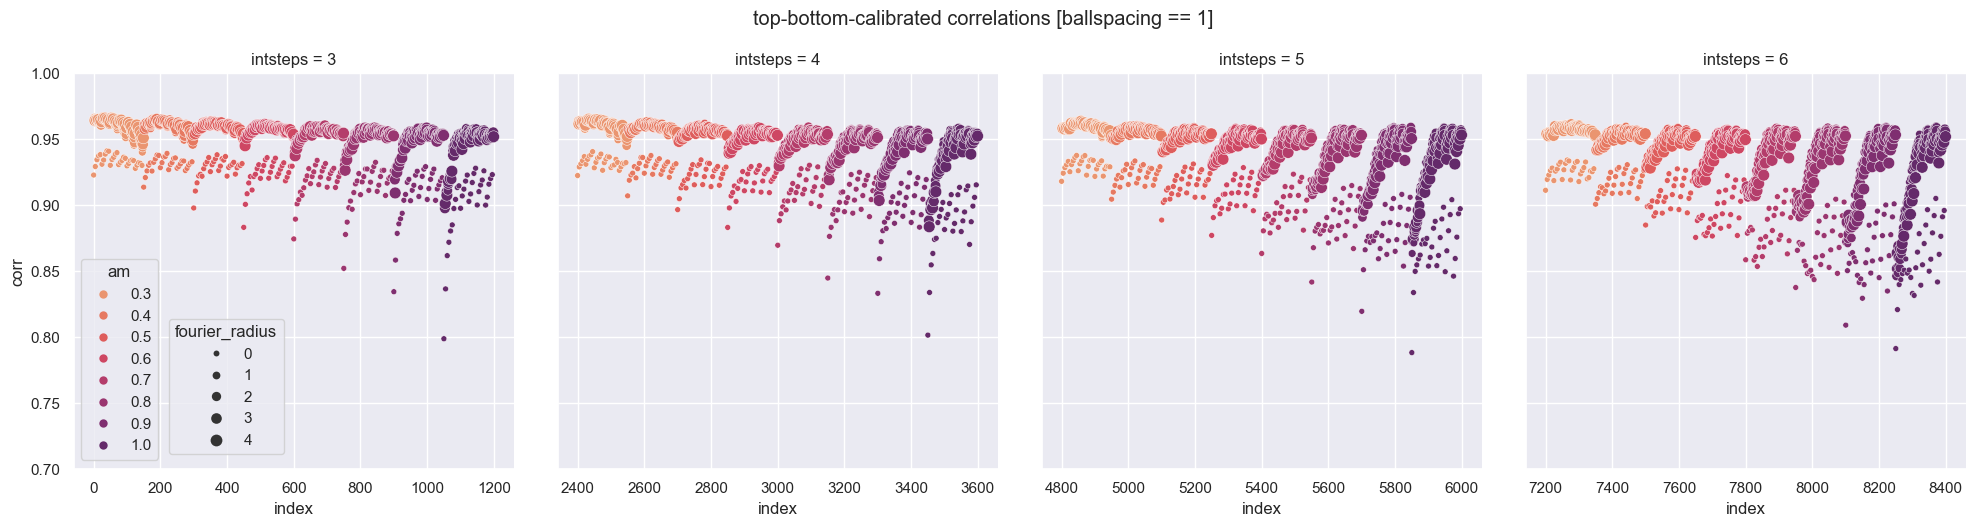

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

df_filter = 'ballspacing == 1'

def plot_correlation(df, df_filter, y_col, title_prefix, ylims=[0.7, 1.0]):
    # 1. Initialize the relplot using the explicitly passed dataframe and filter
    g = sns.relplot(
        data=df.query(df_filter),
        x='index',
        y=y_col,
        col='intsteps',
        size='fourier_radius',
        hue='am',
        palette="flare",
        hue_order=[0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
        height=5, 
        aspect=1, 
        facet_kws={'sharex': False, 'legend_out': False}
    )
    
    g.set(ylim=ylims)

    # 2. Extract and split the combined legend
    ax_leg = g.facet_axis(0, 0)
    old_legend = ax_leg.get_legend()
    
    handles = old_legend.legend_handles
    labels = [t.get_text() for t in old_legend.get_texts()]
    old_legend.remove()

    am_idx = labels.index('am')
    fr_idx = labels.index('fourier_radius')

    # Left column legend (am)
    leg_am = ax_leg.legend(
        handles[am_idx+1 : fr_idx], labels[am_idx+1 : fr_idx],
        title="am", ncol=1, loc="upper left", bbox_to_anchor=(0.0, 0.55)
    )
    ax_leg.add_artist(leg_am) 

    # Right column legend (fourier_radius)
    ax_leg.legend(
        handles[fr_idx+1 :], labels[fr_idx+1 :],
        title="fourier_radius", ncol=1, loc="upper left", bbox_to_anchor=(0.2, 0.4)
    )

    # 3. Final layout adjustments
    g.fig.suptitle(f'{title_prefix} correlations [{df_filter}]', y=1.05)
    plt.subplots_adjust(wspace=0.1)
    plt.show()
    return g

# --- Execute Plotting ---
plt.close('all')
sns.set_theme()

# Now it's explicitly clear what data and filter each plot relies on
ylims=[0.7, 1.0]
g1 = plot_correlation(caldf, df_filter, 'corr_top', 'top-side', ylims=ylims)
g2 = plot_correlation(caldf, df_filter, 'corr_bot', 'bottom-side', ylims=ylims)
g3 = plot_correlation(caldf, df_filter, 'corr', 'top-bottom-calibrated', ylims=ylims)   

In [9]:
caldf.loc[[caldf['corr_top'].idxmax(), caldf['corr_bot'].idxmax()]]


,intsteps,ballspacing,am,dp,sigma_factor,fourier_radius,corr,corr_top,corr_bot,MAE_cal_vx,MAE_cal_vx_top,MAE_cal_vx_bot,RMSE_cal_vx_top,MAE_discrep,MAPE,MAPD,p_top_0,p_bot_0
index,,,,,,,,,,,,,,,,,,
26,3,1,0.3,0.15,1.0,1,0.967094,0.962366,0.956154,99.66000,106.476373,113.292478,133.185029,67.138595,14.808920,10.418147,6.048227,7.918576
53,3,1,0.3,0.20,1.0,3,0.966594,0.961285,0.957900,99.54768,106.253183,110.771447,133.330934,60.951564,15.035973,9.376929,5.751825,7.230302


In [12]:
caldf.loc[[caldf['p_top_0'].idxmin(), caldf['p_bot_0'].idxmin()]]

,intsteps,ballspacing,am,dp,sigma_factor,fourier_radius,corr,corr_top,corr_bot,MAE_cal_vx,MAE_cal_vx_top,MAE_cal_vx_bot,RMSE_cal_vx_top,MAE_discrep,MAPE,MAPD,p_top_0,p_bot_0
index,,,,,,,,,,,,,,,,,,
9450,6,2,1.0,0.1,1.0,0,0.68279,0.574356,0.590499,284.66616,354.427761,357.638482,443.851078,241.056103,36.627558,43.513859,1.423302,1.513297
9450,6,2,1.0,0.1,1.0,0,0.68279,0.574356,0.590499,284.66616,354.427761,357.638482,443.851078,241.056103,36.627558,43.513859,1.423302,1.513297


In [15]:
caldf.query('intsteps == 3 & ballspacing == 1 & am == 0.3 & dp == 0.15 & sigma_factor == 1.0 & fourier_radius == 1')


/var/folders/n5/00g4j6_15_z64rym5hbbgbvc0000gq/T/ipykernel_43035/369951883.py:1: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  caldf.query('intsteps == 3 & ballspacing == 1 & am == 0.3 & dp == 0.15 & sigma_factor == 1.0 & fourier_radius == 1')


,intsteps,ballspacing,am,dp,sigma_factor,fourier_radius,corr,corr_top,corr_bot,MAE_cal_vx,MAE_cal_vx_top,MAE_cal_vx_bot,RMSE_cal_vx_top,MAE_discrep,MAPE,MAPD,p_top_0,p_bot_0
index,,,,,,,,,,,,,,,,,,
26,3,1,0.3,0.15,1.0,1,0.967094,0.962366,0.956154,99.66,106.476373,113.292478,133.185029,67.138595,14.80892,10.418147,6.048227,7.918576


/var/folders/n5/00g4j6_15_z64rym5hbbgbvc0000gq/T/ipykernel_43035/2134712542.py:4: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  data=caldf.query(df_filter),


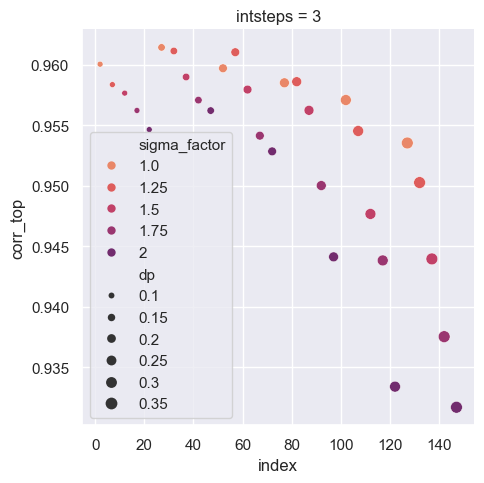

In [19]:
df_filter = 'ballspacing == 1 & intsteps == 3 & am == 0.3 & fourier_radius == 2'    

g = sns.relplot(
        data=caldf.query(df_filter),
        x='index',
        y='corr_top',
        col='intsteps',
        size='dp',
        hue='sigma_factor',
        palette="flare",
        hue_order=[1.0, 1.25, 1.5, 1.75, 2],
        height=5, 
        aspect=1, 
        facet_kws={'sharex': False, 'legend_out': False}
    )

/var/folders/n5/00g4j6_15_z64rym5hbbgbvc0000gq/T/ipykernel_43035/2844267760.py:6: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  g1 = sns.FacetGrid(caldf.query(df_filter), col='sigma_factor', height=3, aspect=1.2)
/var/folders/n5/00g4j6_15_z64rym5hbbgbvc0000gq/T/ipykernel_43035/2844267760.py:11: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  g2 = sns.FacetGrid(caldf.query(df_filter), col='sigma_factor', height=3, aspect=1.2)
/var/folders/n5/00g4j6_15_z64rym5hbbgbvc0000gq/T/ipykernel_43035/2844267760.py:16: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  g3 = sns.FacetGrid(caldf.query(df_filter), col='sigma_factor', height=3, aspect=1.2)


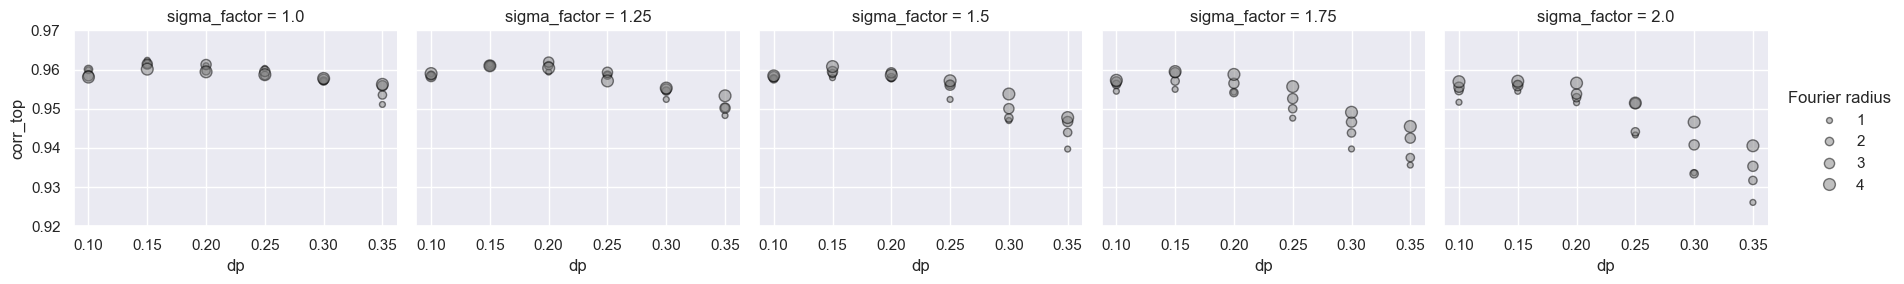

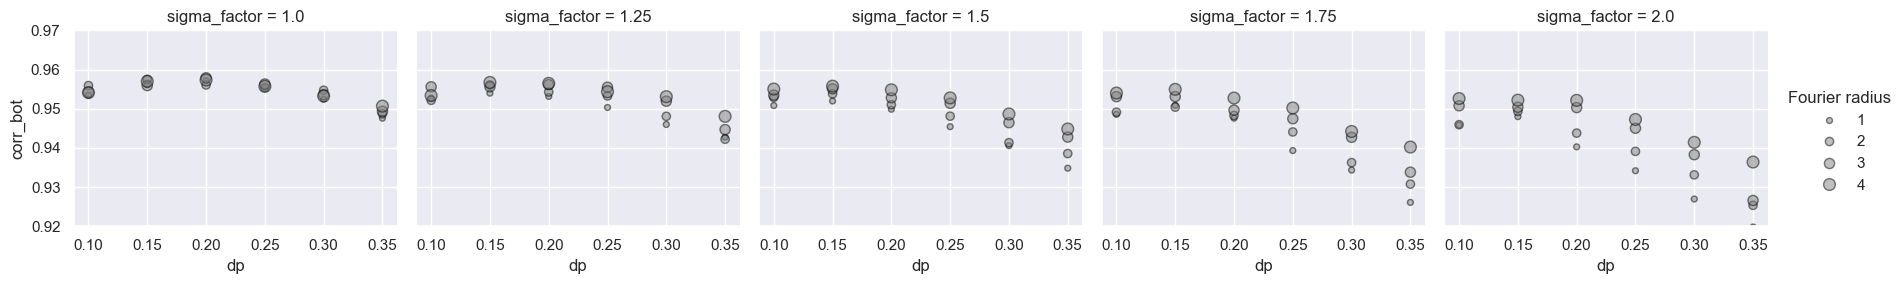

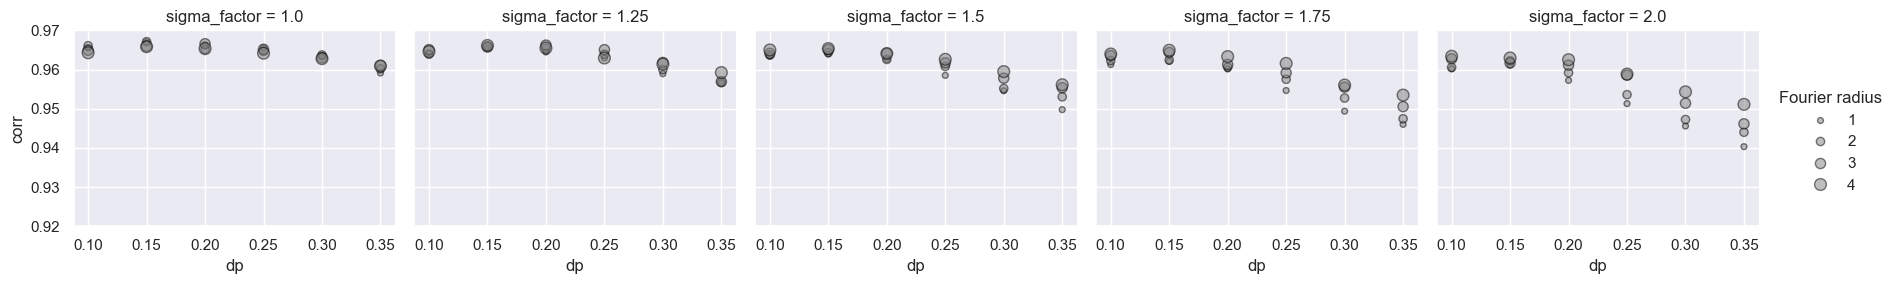

In [20]:
df_filter = 'ballspacing == 1 & intsteps == 3 & am == 0.3 & fourier_radius > 0'

plt.close('all')
sns.set_theme()

g1 = sns.FacetGrid(caldf.query(df_filter), col='sigma_factor', height=3, aspect=1.2)
g1.map_dataframe(sns.scatterplot, x='dp', y='corr_top', size='fourier_radius', alpha=0.5, color='gray', edgecolor='black', linewidth=1)
g1.add_legend(title='Fourier radius')
g1.set(ylim=(0.92, 0.97))

g2 = sns.FacetGrid(caldf.query(df_filter), col='sigma_factor', height=3, aspect=1.2)
g2.map_dataframe(sns.scatterplot, x='dp', y='corr_bot', size='fourier_radius', alpha=0.5, color='gray', edgecolor='black', linewidth=1)
g2.add_legend(title='Fourier radius')
g2.set(ylim=(0.92, 0.97))

g3 = sns.FacetGrid(caldf.query(df_filter), col='sigma_factor', height=3, aspect=1.2)
g3.map_dataframe(sns.scatterplot, x='dp', y='corr', size='fourier_radius', alpha=0.5, color='gray', edgecolor='black', linewidth=1)
g3.add_legend(title='Fourier radius')
g3.set(ylim=(0.92, 0.97))

plt.show()

/var/folders/n5/00g4j6_15_z64rym5hbbgbvc0000gq/T/ipykernel_43035/3961554915.py:1: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  h1 = sns.FacetGrid(caldf.query(df_filter), col='sigma_factor', height=3, aspect=1.2)
/var/folders/n5/00g4j6_15_z64rym5hbbgbvc0000gq/T/ipykernel_43035/3961554915.py:5: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  h2 = sns.FacetGrid(caldf.query(df_filter), col='sigma_factor', height=3, aspect=1.2)
/var/folders/n5/00g4j6_15_z64rym5hbbgbvc0000gq/T/ipykernel_43035/3961554915.py:9: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  h3 = sns.FacetGrid(caldf.query(df_filter), col='sigma_factor', height=3, aspect=1.2)


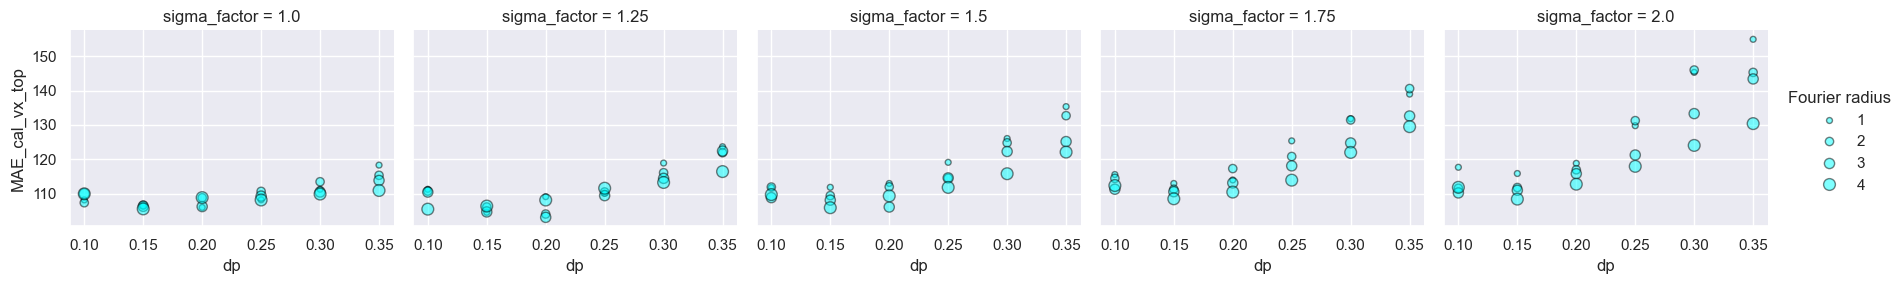

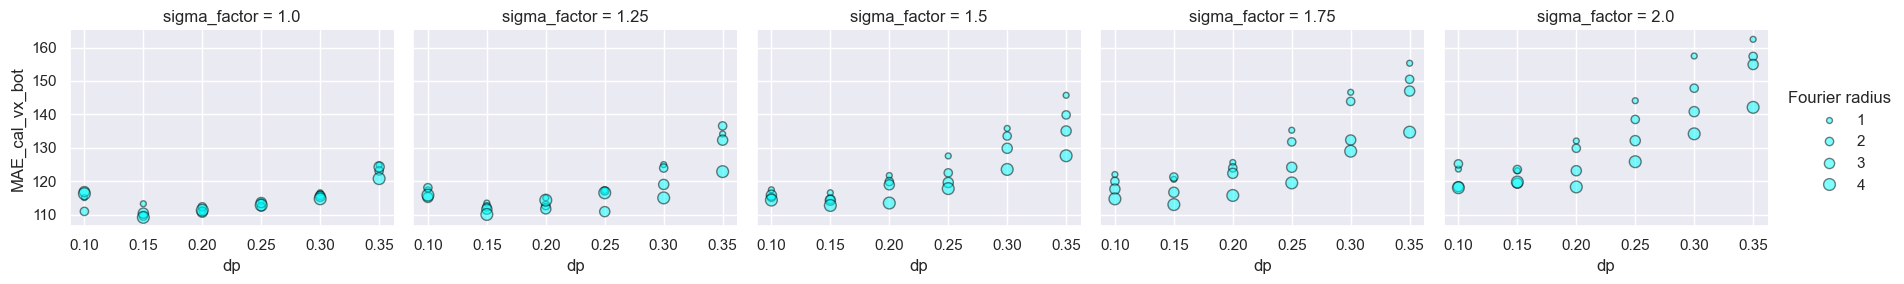

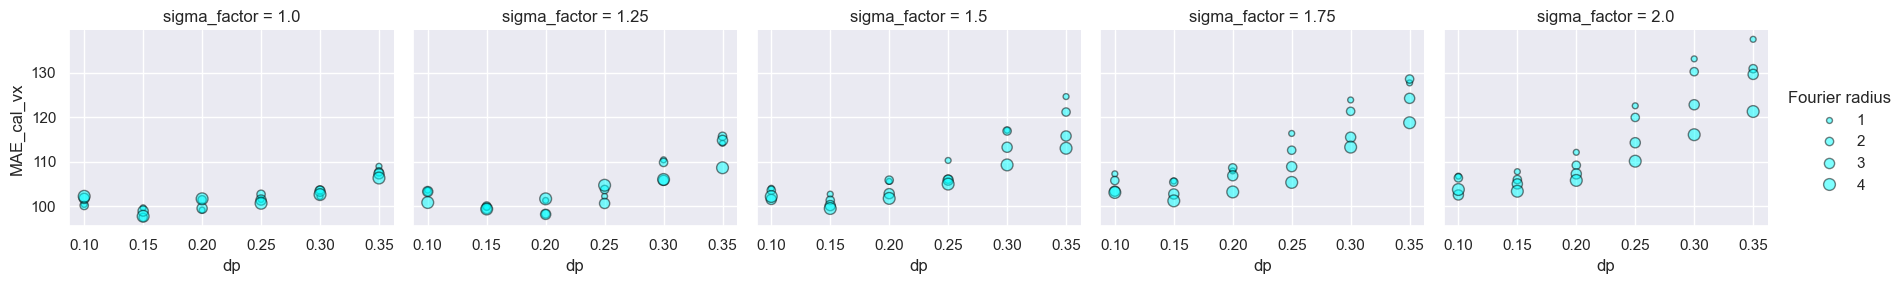

In [21]:
h1 = sns.FacetGrid(caldf.query(df_filter), col='sigma_factor', height=3, aspect=1.2)
h1.map_dataframe(sns.scatterplot, x='dp', y='MAE_cal_vx_top', size='fourier_radius', alpha=0.5, color='cyan', edgecolor='black', linewidth=1)
h1.add_legend(title='Fourier radius')

h2 = sns.FacetGrid(caldf.query(df_filter), col='sigma_factor', height=3, aspect=1.2)
h2.map_dataframe(sns.scatterplot, x='dp', y='MAE_cal_vx_bot', size='fourier_radius', alpha=0.5, color='cyan', edgecolor='black', linewidth=1)
h2.add_legend(title='Fourier radius')

h3 = sns.FacetGrid(caldf.query(df_filter), col='sigma_factor', height=3, aspect=1.2)
h3.map_dataframe(sns.scatterplot, x='dp', y='MAE_cal_vx', size='fourier_radius', alpha=0.5, color='cyan', edgecolor='black', linewidth=1)
h3.add_legend(title='Fourier radius')

plt.show()

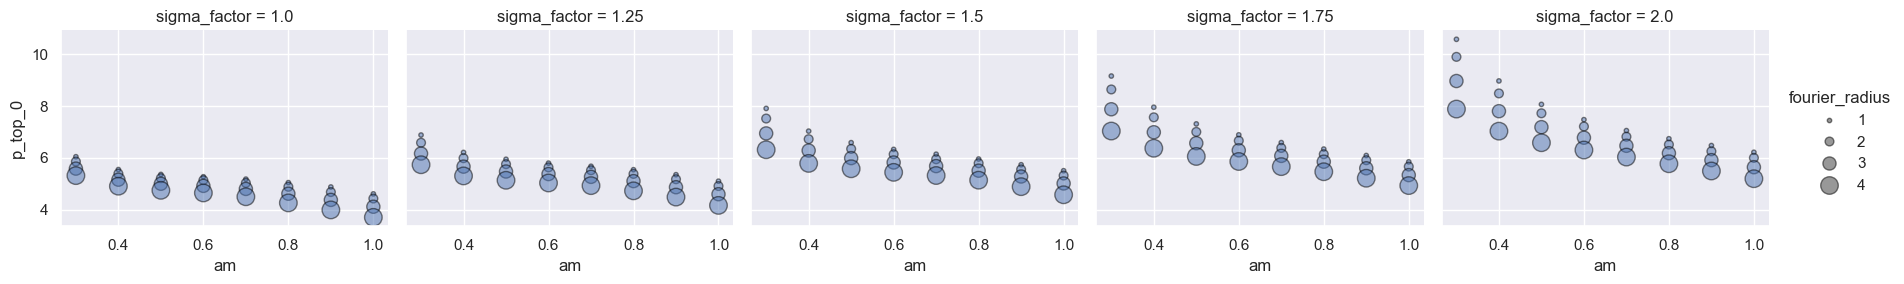

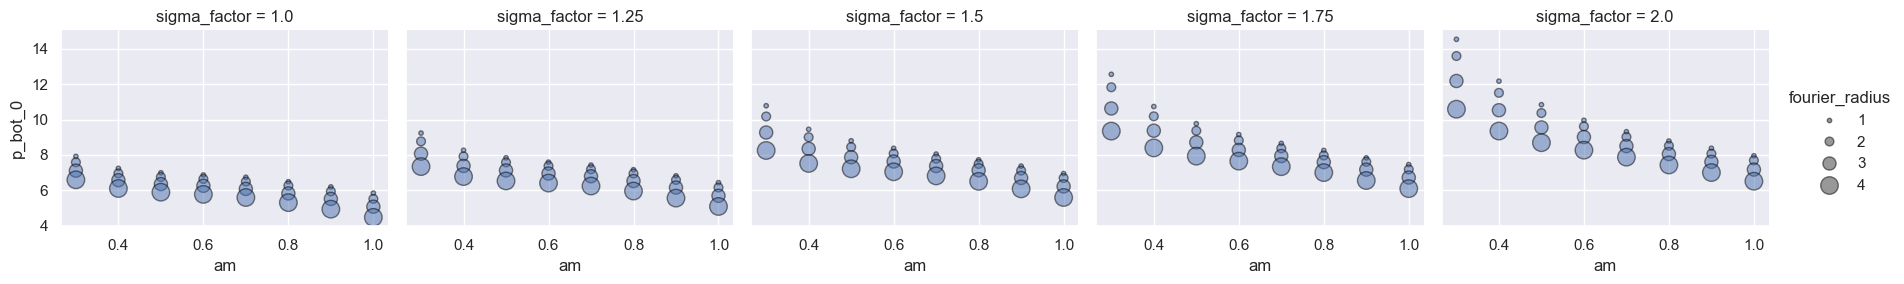

In [23]:
sizes = ((np.arange(1,5)**2)*10).tolist()

df_filter2 = 'ballspacing == 1 & intsteps == 3 & dp == 0.15 & fourier_radius > 0' # 'ballspacing == 1 & intsteps == 3 & am == 0.3 & fourier_radius > 0'

g1 = sns.relplot(
    data=caldf.query(df_filter2),
    x='am',
    y='p_top_0',
    col='sigma_factor',
    size='fourier_radius',
    edgecolor='black',
    linewidth=1,
    sizes=sizes,
    alpha=0.5,
    height=3, aspect=1.2, 
    facet_kws={'sharex':False, 'legend_out':True}
)

g2 = sns.relplot(
    data=caldf.query(df_filter2),
    x='am',
    y='p_bot_0',
    col='sigma_factor',
    size='fourier_radius',
    edgecolor='black',
    linewidth=1,
    sizes=sizes,
    alpha=0.5,
    height=3, aspect=1.2, 
    facet_kws={'sharex':False, 'legend_out':True}
)

plt.show()

In [170]:
caldf.query('intsteps == 3 & am == 0.3 & dp==0.2 & sigma_factor == 1.0 & fourier_radius == 4')

,index,intsteps,ballspacing,am,dp,sigma_factor,fourier_radius,corr,corr_top,corr_bot,MAE_cal_vx,MAE_cal_vx_top,MAE_cal_vx_bot,RMSE_cal_vx_top,MAE_discrep,MAPE,MAPD,p_top_0,p_bot_0
54,54,3,1,0.3,0.2,1.0,4,0.965742,0.959515,0.958027,100.910503,108.357206,111.104859,136.746866,60.97506,14.60674,9.743118,5.423577,6.666287


## What about the discrepancy between top and bottom? 

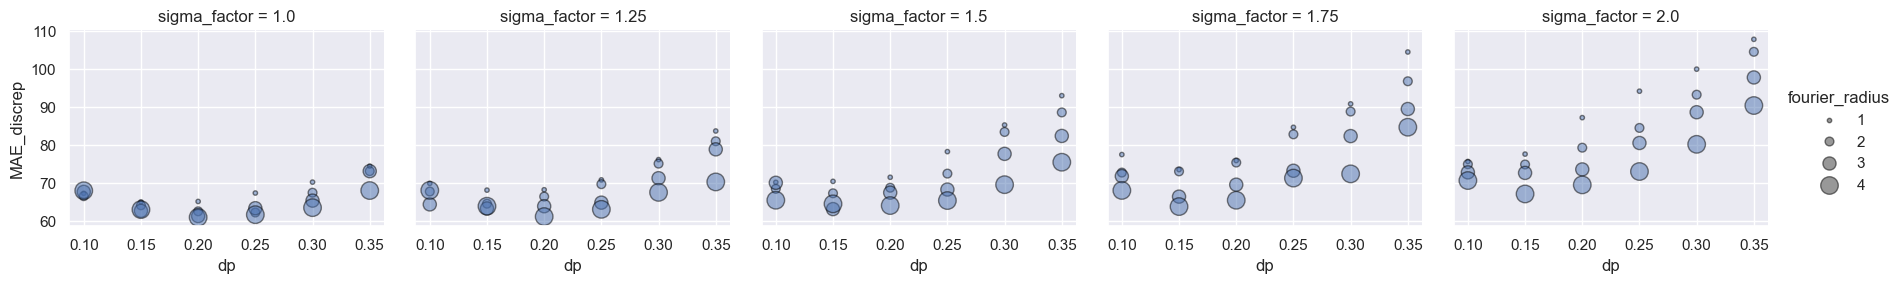

In [160]:
g = sns.relplot(
    data=caldf.query('intsteps == 3 & am == 0.3 & fourier_radius>0'),
    x='dp',
    y='MAE_discrep',
    col='sigma_factor',
    size='fourier_radius',
    edgecolor='black',
    linewidth=1,
    sizes=sizes,
    alpha=0.5,
    height=3, aspect=1.2, 
    facet_kws={'sharex':False, 'legend_out':True}
)

plt.subplots_adjust(wspace=0.1)
plt.show()

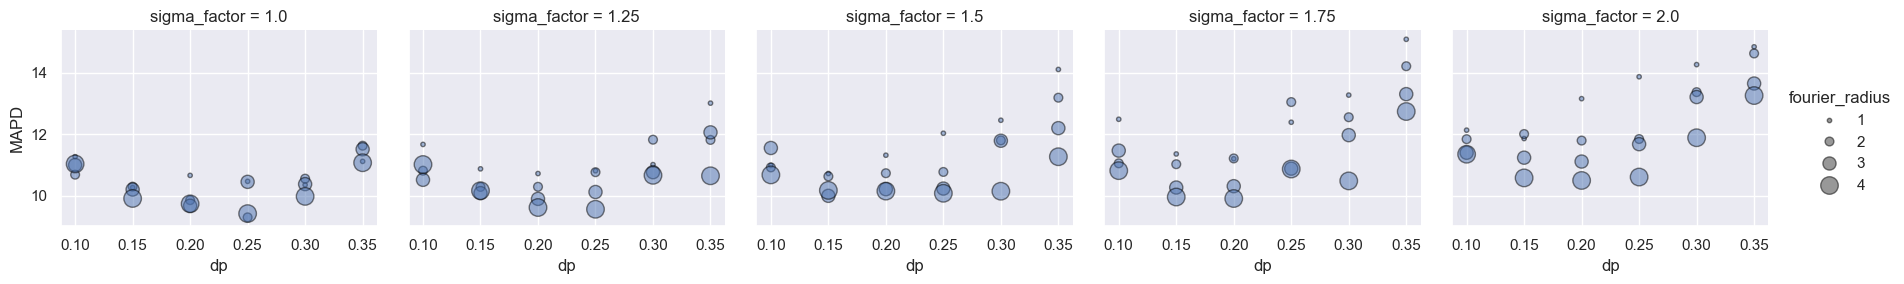

In [163]:
g = sns.relplot(
    data=caldf.query('intsteps == 3 & am == 0.3 & fourier_radius>0'),
    x='dp',
    y='MAPD',
    col='sigma_factor',
    size='fourier_radius',
    edgecolor='black',
    linewidth=1,
    sizes=sizes,
    alpha=0.5,
    height=3, aspect=1.2, 
    facet_kws={'sharex':False, 'legend_out':True}
)

plt.subplots_adjust(wspace=0.1)
plt.show()

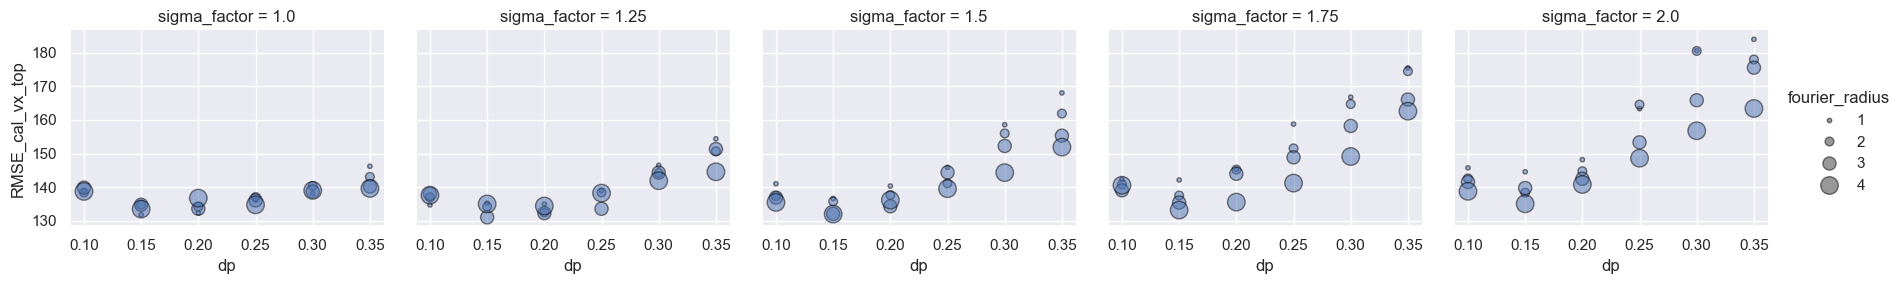

In [164]:
g = sns.relplot(
    data=caldf.query('intsteps == 3 & am == 0.3 & fourier_radius>0'),
    x='dp',
    y='RMSE_cal_vx_top',
    col='sigma_factor',
    size='fourier_radius',
    edgecolor='black',
    linewidth=1,
    sizes=sizes,
    alpha=0.5,
    height=3, aspect=1.2, 
    facet_kws={'sharex':False, 'legend_out':True}
)

plt.subplots_adjust(wspace=0.1)
plt.show()

In [165]:
caldf.query('fourier_radius > 0 & intsteps == 4 & ballspacing == 1 & fourier_radius == 1 & sigma_factor == 2')[['am', 'dp', 'corr_top']].head()

,am,dp,corr_top
2421,0.3,0.10,0.945849
2446,0.3,0.15,0.953832
2471,0.3,0.20,0.950471
2496,0.3,0.25,0.944932
2521,0.3,0.30,0.939479


dp       0.10      0.15      0.20      0.25      0.30      0.35
am                                                             
0.3  0.945849  0.953832  0.950471  0.944932  0.939479  0.932130
0.4  0.946150  0.952682  0.949495  0.947213  0.940824  0.937417
0.5  0.941867  0.948787  0.949607  0.946582  0.941664  0.942657
0.6  0.935254  0.943830  0.948148  0.949391  0.945232  0.939076
0.7  0.921140  0.938998  0.946931  0.944985  0.946000  0.942367


<Axes: xlabel='dp', ylabel='am'>

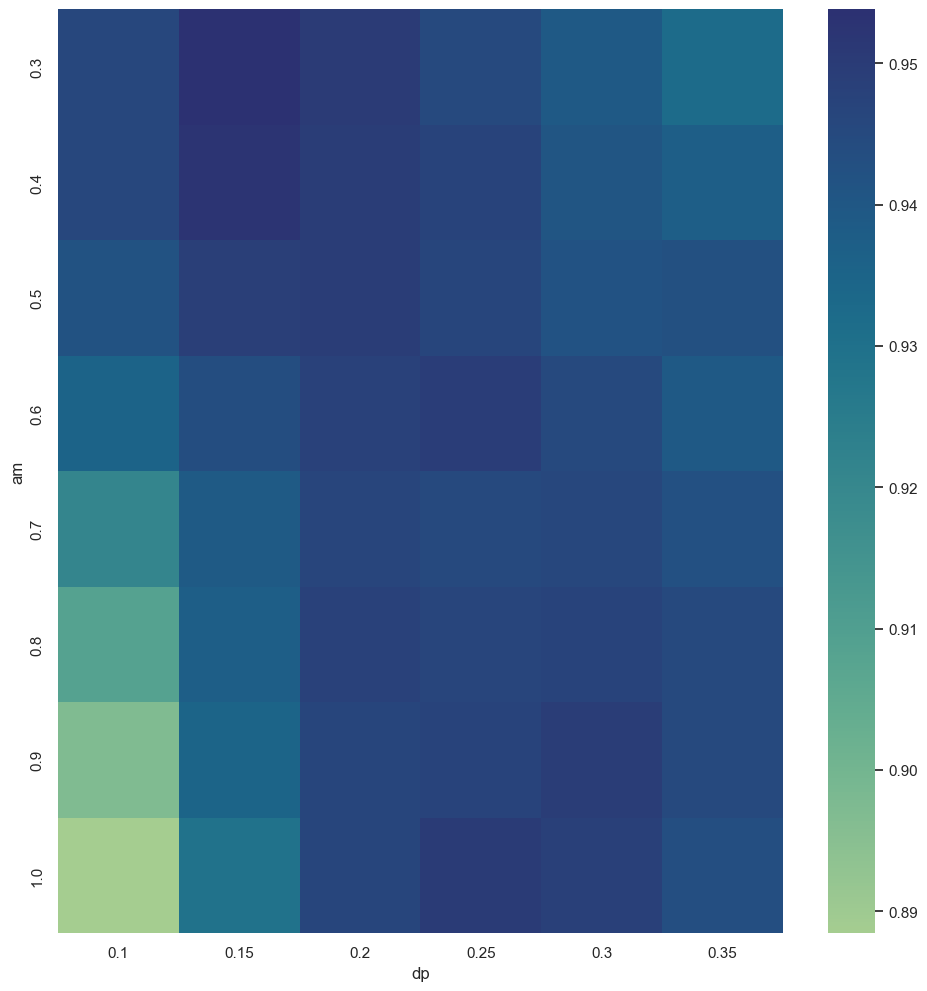

In [166]:
pt = caldf.query('fourier_radius > 0 & intsteps == 4 & ballspacing == 1 & fourier_radius == 1 & sigma_factor == 2')[['am', 'dp', 'corr_top']].pivot(index='am', columns='dp', values= 'corr_top')
print(pt.head())
sns.heatmap(pt, cmap='crest')

In [167]:
def draw_heatmap(*args, **kwargs):
    data = kwargs.pop('data')
    heatmap_data = data.pivot(index=args[1], columns=args[0], values=args[2])
    ax = sns.heatmap(heatmap_data, **kwargs)
    ax.invert_yaxis()

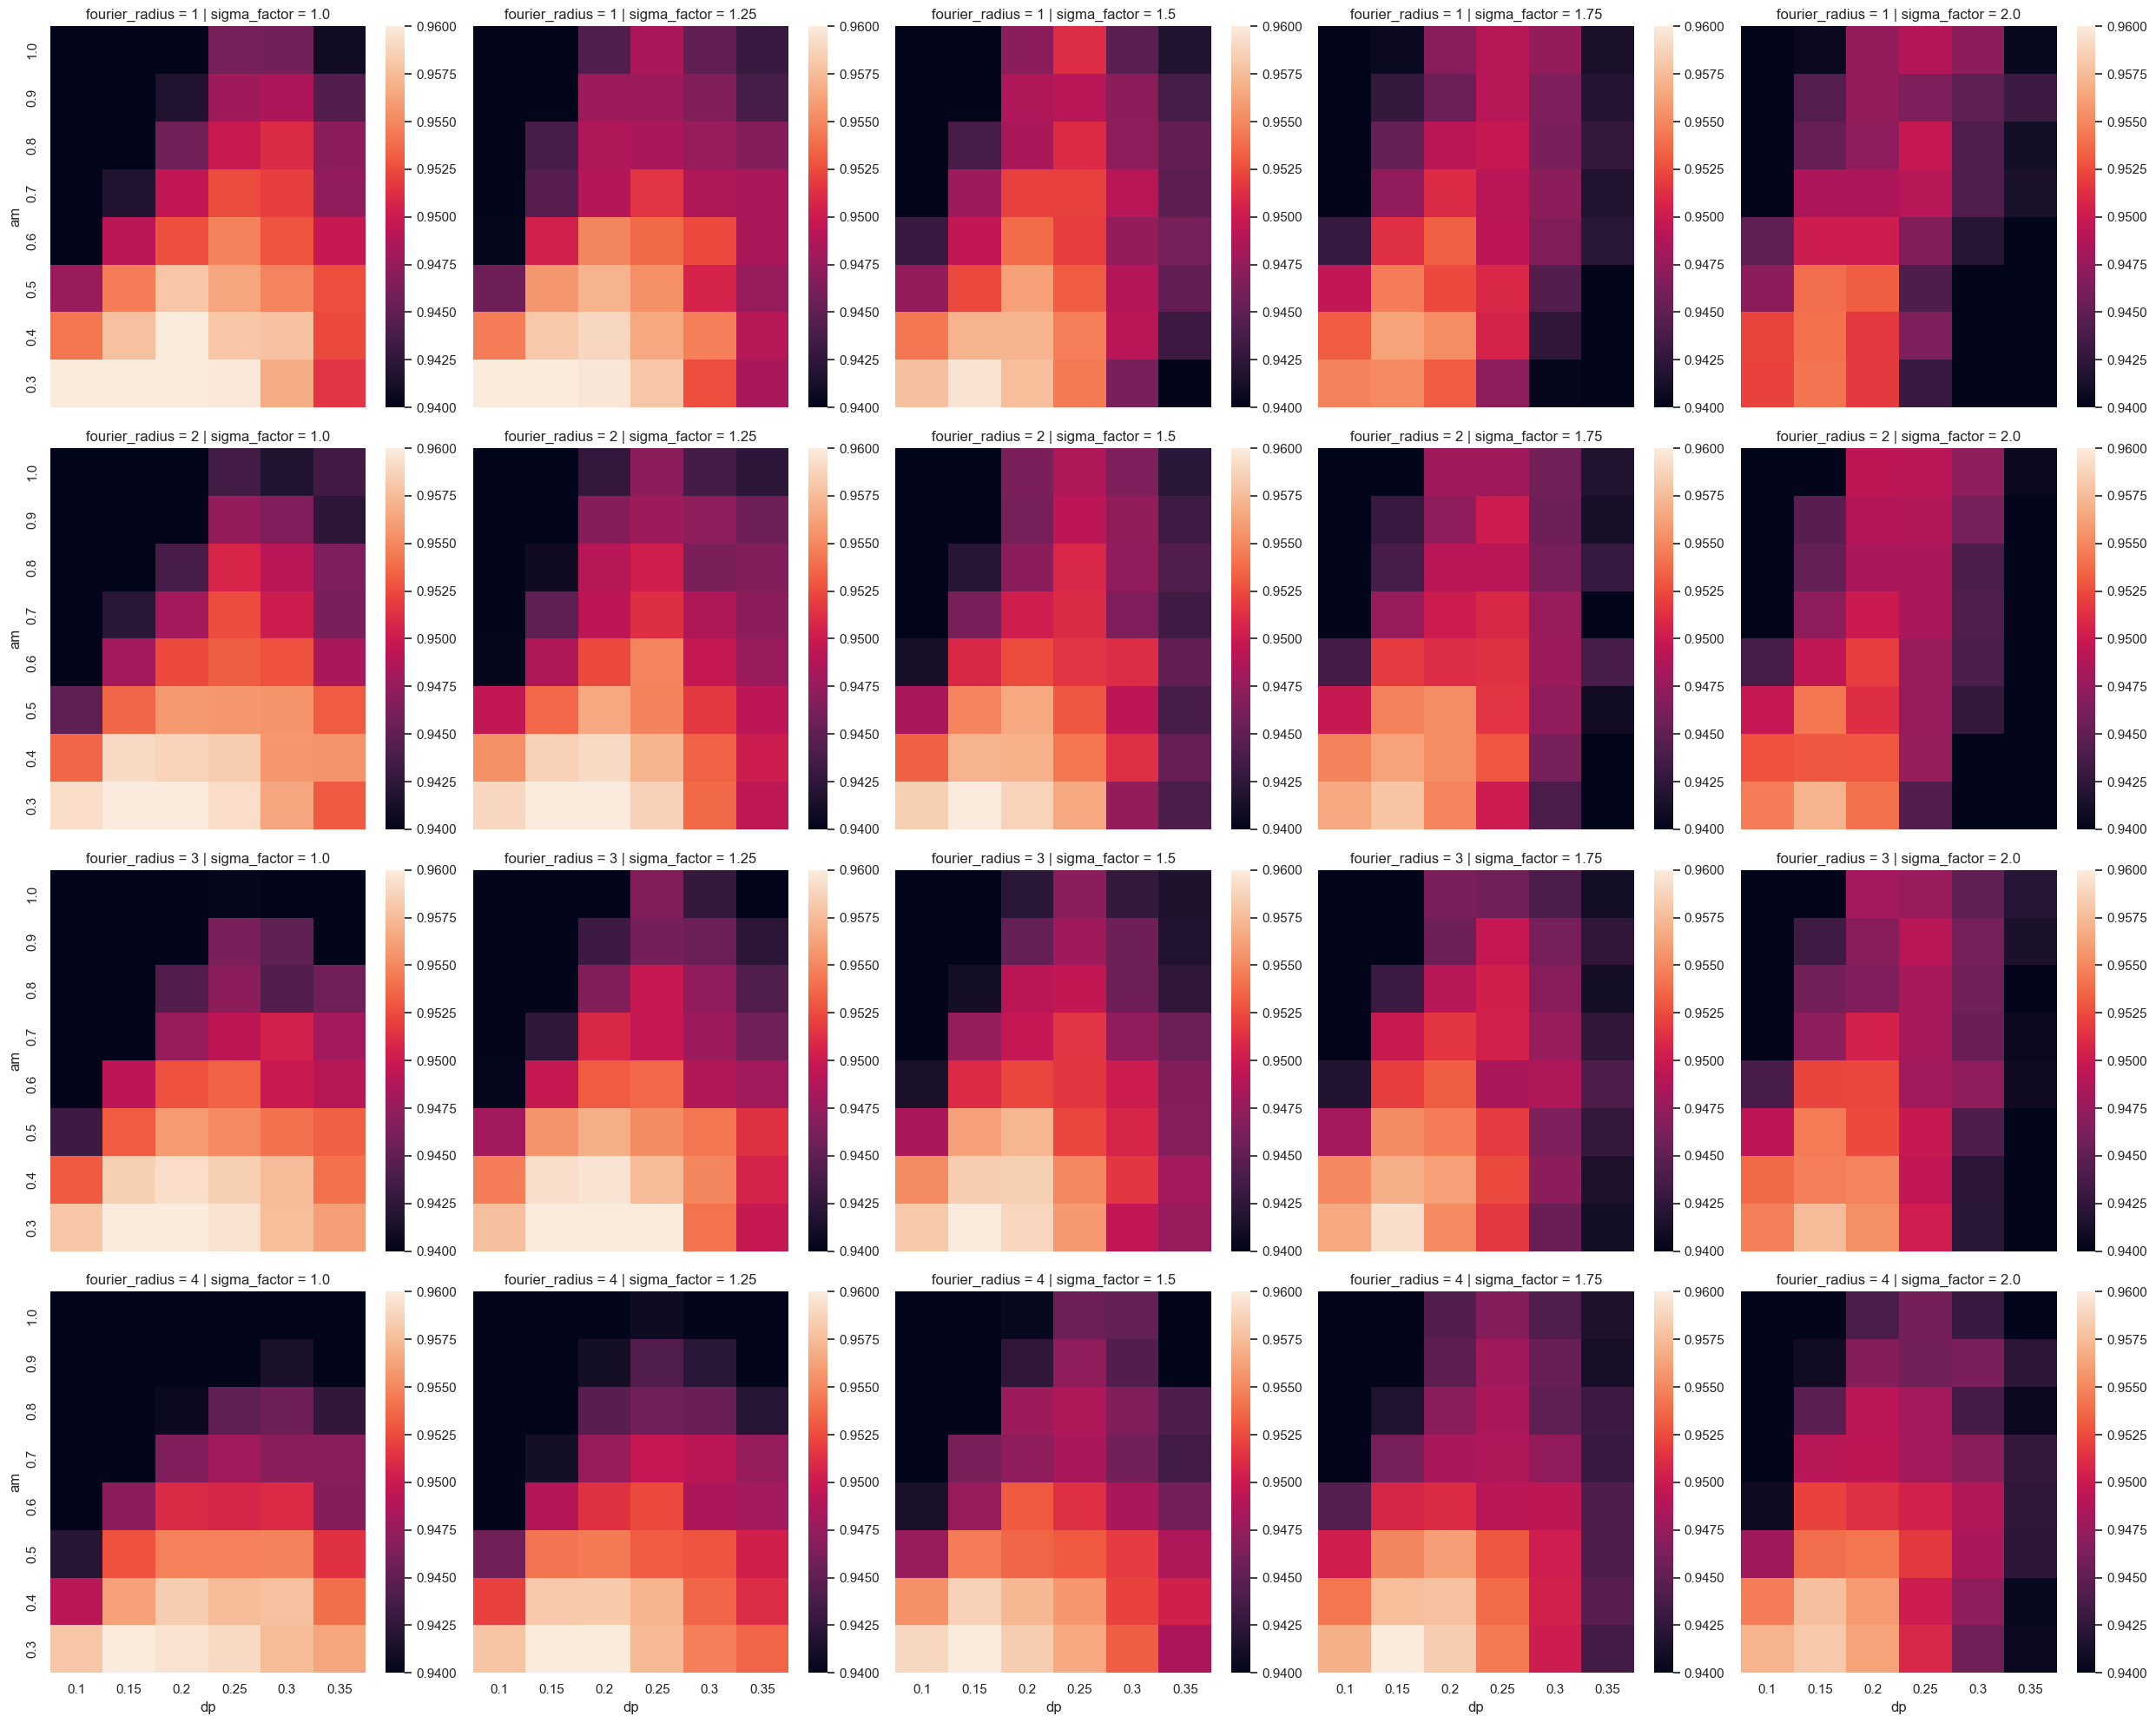

In [174]:
sns.set(font_scale=1) 

vmin=0.94
vmax=0.96
data = caldf.query('fourier_radius > 0 & intsteps == 3 & ballspacing == 1')
fg = sns.FacetGrid(data, col='sigma_factor', row='fourier_radius', height=5, aspect=1)
fg.map_dataframe(draw_heatmap, 'dp', 'am', 'corr_top', vmin=vmin, vmax=vmax, cbar=True)

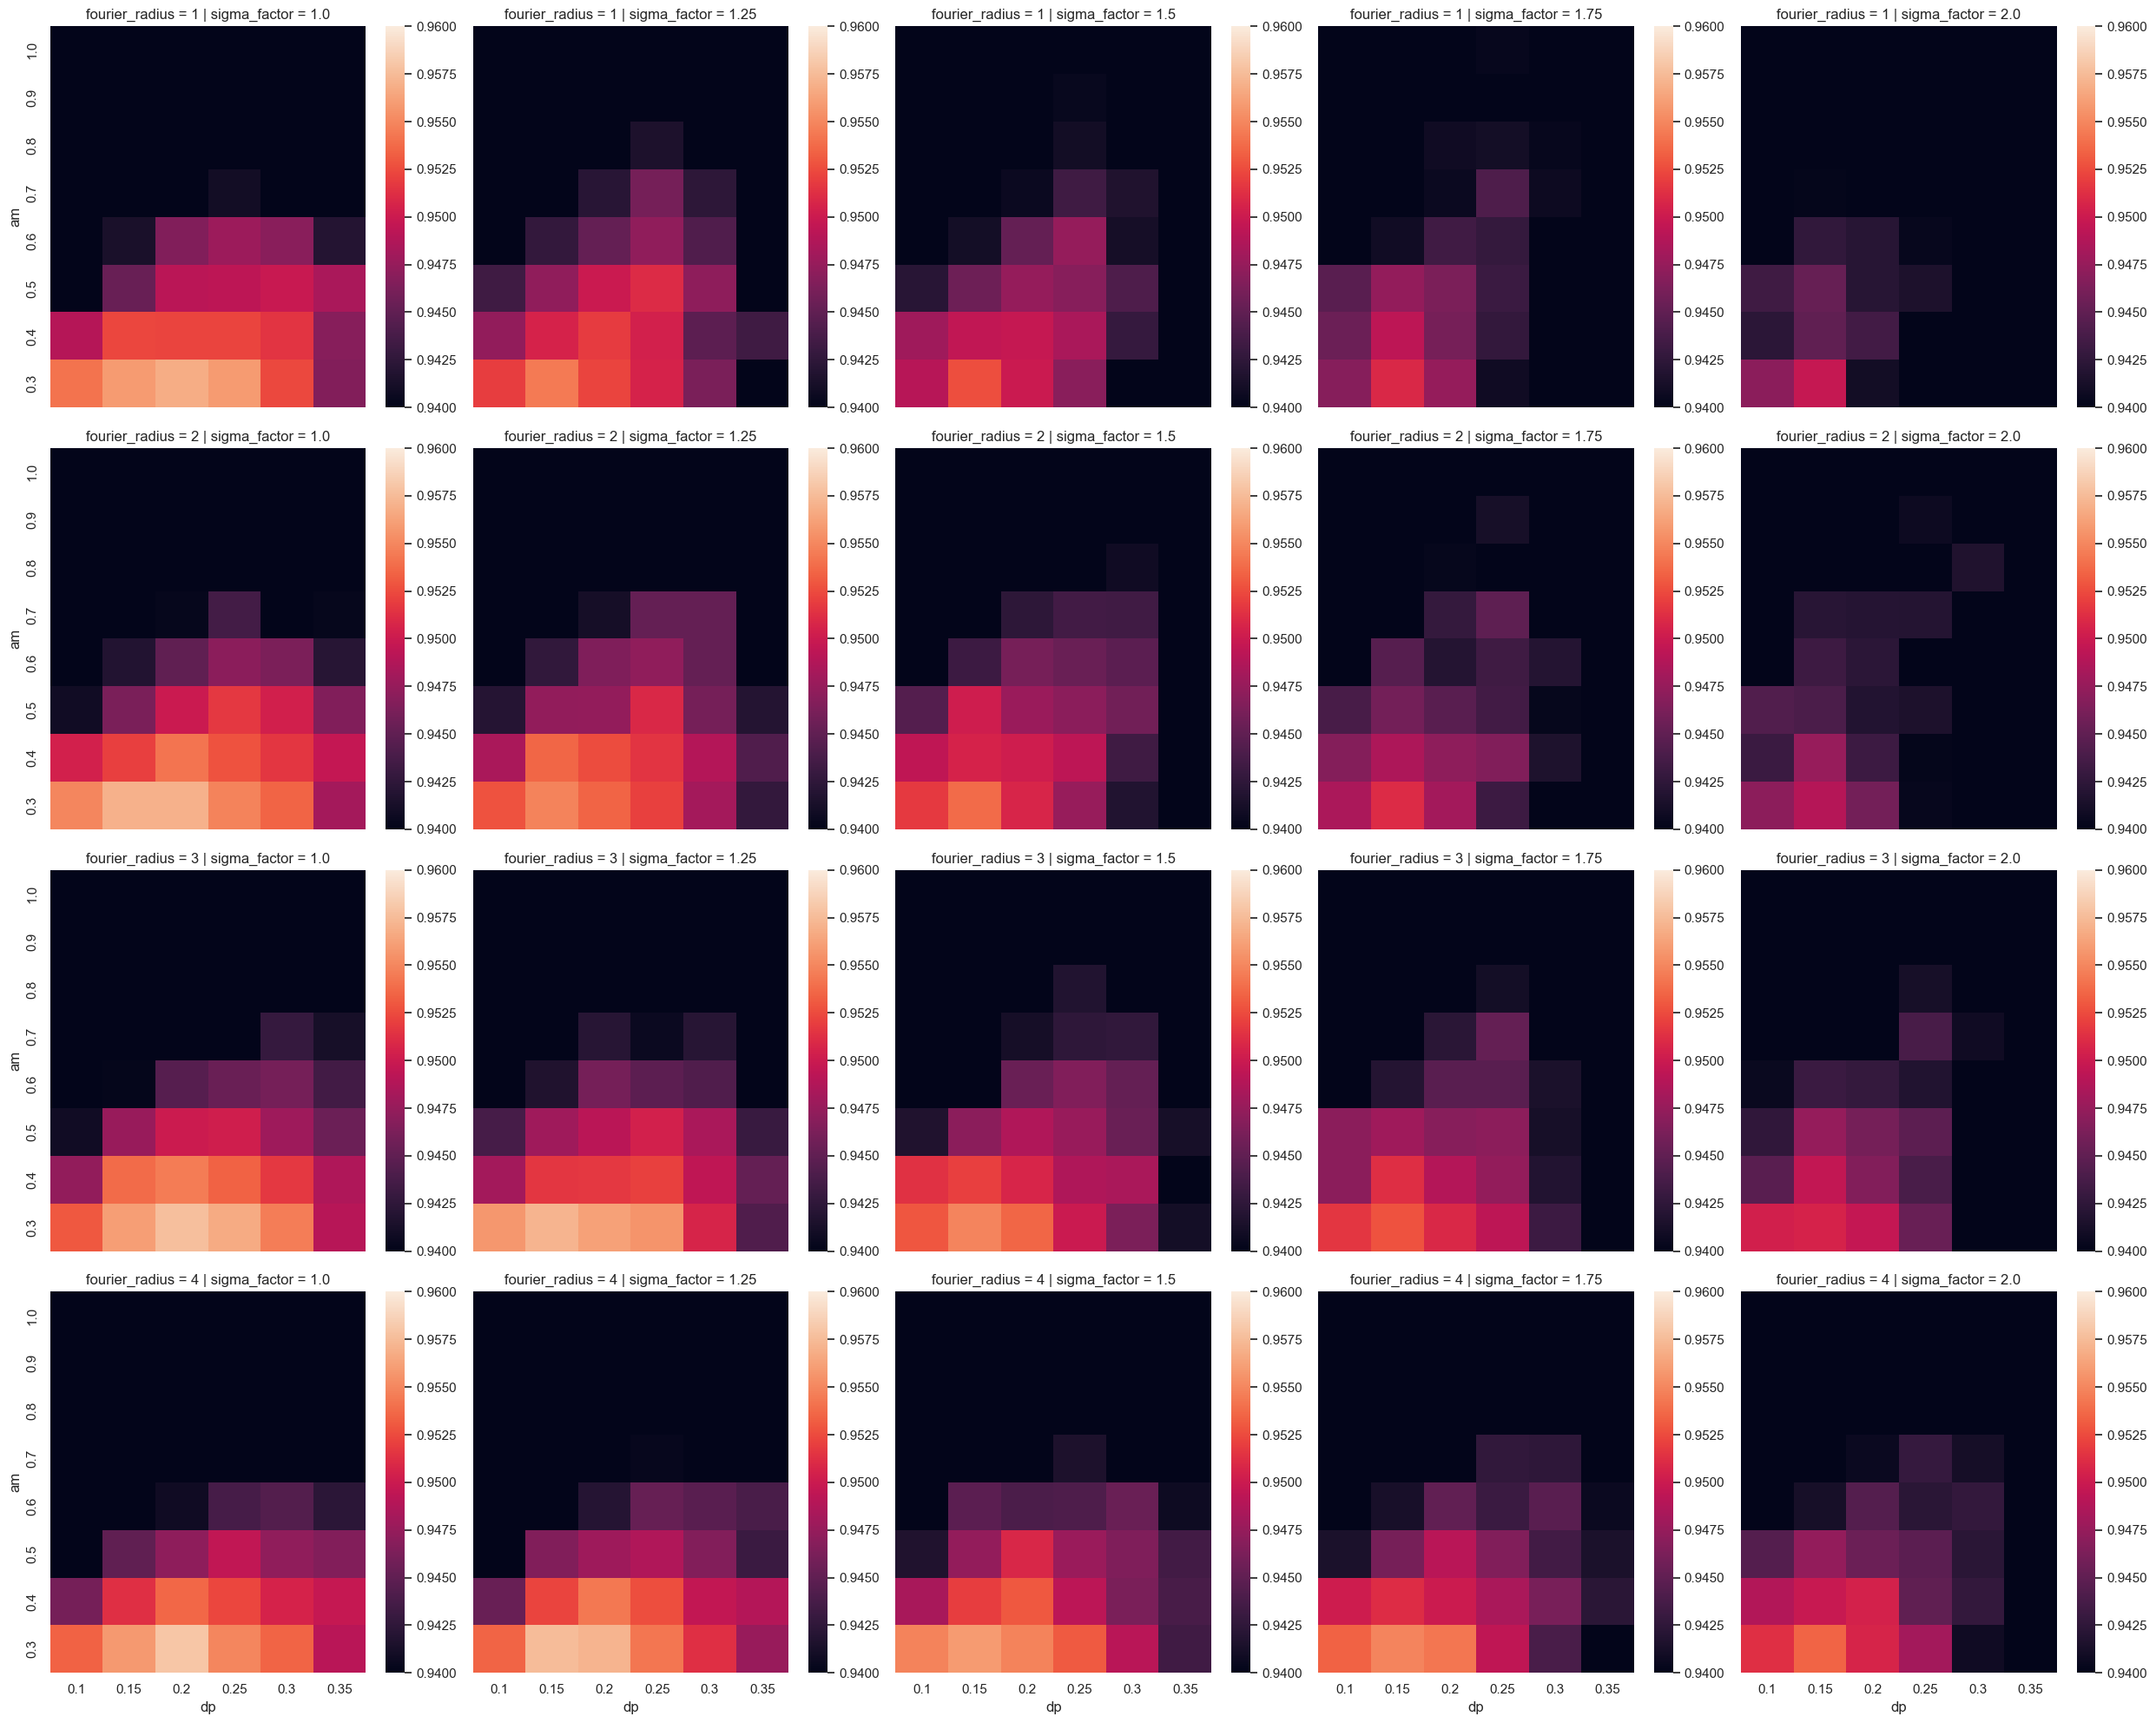

In [175]:
data = caldf.query('fourier_radius > 0 & intsteps == 3 & ballspacing == 1')
fg = sns.FacetGrid(data, col='sigma_factor', row='fourier_radius', height=5, aspect=1)
fg.map_dataframe(draw_heatmap, 'dp', 'am', 'corr_bot', vmin=vmin, vmax=vmax, cbar=True)

In [45]:
# unit in m/s for Stein simulation for 1 px / frame interval
u = 368000 / 60
trange = [0, 60]
fwhm = 7
trim = 10 # Same as Benoit
fov = np.s_[trim:-trim:fwhm, trim:-trim:fwhm]
# Get Stein velocity
datadir_stein = os.path.join(os.environ['DATA'], 'Ben/SteinSDO/')
svx_files = sorted(glob.glob(os.path.join(datadir_stein, 'SDO_vx*.fits')))
svy_files = sorted(glob.glob(os.path.join(datadir_stein, 'SDO_vy*.fits')))
vx_stein, vy_stein = load_vel_mean((svx_files, svy_files), trange)